# Notebook 05 – Profile Interpretation

## Objective

This notebook integrates the participant engagement profiles identified through unsupervised clustering with quantitative behavioural measures and NLP-derived therapist sentiment. The aim is to characterise the identified engagement profiles, examine whether therapist sentiment differs across profiles, explore relationships between sentiment and quantitative engagement measures, and investigate participant characteristics associated with profile membership.

The analysis is designed to address the remaining research questions concerning behavioural differences between engagement profiles, participant characteristics associated with profile membership, and relationships between NLP-derived sentiment and quantitative engagement measures.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Define Project Paths

Paths to the processed datasets and output figures are defined to maintain a reproducible project structure.

In [2]:
processed_folder = Path("../data/processed")
figures_folder = Path("../figures")

figures_folder.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", processed_folder.resolve())
print("Figures folder:", figures_folder.resolve())

Processed data folder: C:\Users\puspi\OneDrive\Desktop\demo-testing\asd-interventions\data\processed
Figures folder: C:\Users\puspi\OneDrive\Desktop\demo-testing\asd-interventions\figures


## 3. Load Analysis Datasets

The participant-level clustering results and NLP-enriched quantitative feature dataset were loaded from the processed data directory. These datasets will be validated and merged using the participant identifier before conducting profile interpretation.

In [3]:
cluster_path = processed_folder / "clustered_participant_data.csv"
nlp_path = processed_folder / "participant_features_with_nlp.csv"

cluster_df = pd.read_csv(cluster_path)
nlp_features_df = pd.read_csv(nlp_path)

print("Clustering dataset shape:", cluster_df.shape)
print("NLP-enriched dataset shape:", nlp_features_df.shape)

print("\nClustering dataset:")
display(cluster_df.head())

print("\nNLP-enriched dataset:")
display(nlp_features_df.head())

Clustering dataset shape: (32, 20)
NLP-enriched dataset shape: (32, 18)

Clustering dataset:


,Participant id,Number_of_sessions,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage,Cluster_2,Cluster_5,Cluster,Hierarchical_Cluster
0,101,8,2.437500,2.125000,6.250000,2.562500,2.812500,2.571429,2.384615,2.000000,1.916667,2.083333,1.538462,1.461538,60.0000,51.904762,0,3,0,0
1,102,8,1.750000,1.687500,4.000000,1.750000,2.250000,1.812500,1.437500,0.800000,0.600000,0.750000,0.250000,0.375000,160.0000,64.895833,1,1,1,1
2,104,8,2.187500,1.687500,5.333333,2.250000,2.266667,2.200000,1.666667,1.285714,0.933333,1.285714,0.666667,1.066667,6.2500,64.000000,1,1,1,1
3,105,8,3.562500,2.875000,7.625000,3.437500,3.187500,3.500000,2.000000,2.375000,2.125000,2.312500,1.875000,2.187500,42.1875,80.625000,0,0,0,0
4,106,8,1.533333,1.666667,3.800000,1.666667,1.500000,1.866667,1.000000,1.000000,0.600000,0.933333,0.466667,0.666667,77.5000,61.047619,1,1,1,1



NLP-enriched dataset:


,Participant id,Number_of_sessions,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage,Number_of_text_sessions,Mean_sentiment_compound
0,101,8,2.437500,2.125000,6.250000,2.562500,2.812500,2.571429,2.384615,2.000000,1.916667,2.083333,1.538462,1.461538,NaN,51.904762,NaN,NaN
1,102,8,1.750000,1.687500,4.000000,1.750000,2.250000,1.812500,1.437500,0.800000,0.600000,0.750000,0.250000,0.375000,160.0000,64.895833,8.0,0.472013
2,104,8,2.187500,1.687500,5.333333,2.250000,2.266667,2.200000,1.666667,1.285714,0.933333,1.285714,0.666667,1.066667,6.2500,64.000000,7.0,0.233414
3,105,8,3.562500,2.875000,7.625000,3.437500,3.187500,3.500000,2.000000,2.375000,2.125000,2.312500,1.875000,2.187500,42.1875,80.625000,6.0,0.179550
4,106,8,1.533333,1.666667,3.800000,1.666667,1.500000,1.866667,1.000000,1.000000,0.600000,0.933333,0.466667,0.666667,77.5000,61.047619,7.0,-0.153443


In [4]:
print("Clustering shape:", cluster_df.shape)
print("NLP shape:", nlp_features_df.shape)

print(
    "Participant IDs identical:",
    set(cluster_df["Participant id"]) ==
    set(nlp_features_df["Participant id"])
)

print(
    "Duplicate IDs in clustering data:",
    cluster_df["Participant id"].duplicated().sum()
)

print(
    "Duplicate IDs in NLP data:",
    nlp_features_df["Participant id"].duplicated().sum()
)

Clustering shape: (32, 20)
NLP shape: (32, 18)
Participant IDs identical: True
Duplicate IDs in clustering data: 0
Duplicate IDs in NLP data: 0


## 4. Integrate Clustering and NLP Results

The NLP-derived participant-level variables were merged with the clustering dataset using the participant identifier. Only the NLP-specific variables were added because the quantitative participant-level measures were already present in the clustering dataset. This avoids duplication of the existing quantitative features.

In [5]:
analysis_df = cluster_df.merge(
    nlp_features_df[
        [
            "Participant id",
            "Number_of_text_sessions",
            "Mean_sentiment_compound"
        ]
    ],
    on="Participant id",
    how="left"
)

print("Integrated dataset shape:", analysis_df.shape)

analysis_df[
    [
        "Participant id",
        "Cluster",
        "Hierarchical_Cluster",
        "Number_of_text_sessions",
        "Mean_sentiment_compound"
    ]
].head(10)

Integrated dataset shape: (32, 22)


,Participant id,Cluster,Hierarchical_Cluster,Number_of_text_sessions,Mean_sentiment_compound
0,101,0,0,NaN,NaN
1,102,1,1,8.0,0.472013
2,104,1,1,7.0,0.233414
3,105,0,0,6.0,0.179550
4,106,1,1,7.0,-0.153443
5,107,0,0,4.0,0.105375
6,109,0,0,6.0,0.241100
7,110,0,0,6.0,0.587833
8,111,0,0,NaN,NaN
9,112,0,0,6.0,0.297600


## 5. Validation of the Integrated Dataset

The integrated dataset was checked for participant duplication, cluster distribution, and availability of NLP-derived sentiment data before conducting profile-level comparisons.

In [6]:
print("Dataset shape:", analysis_df.shape)

print("\nDuplicate participant IDs:")
print(analysis_df["Participant id"].duplicated().sum())

print("\nFinal cluster sizes:")
print(analysis_df["Cluster"].value_counts().sort_index())

print("\nParticipants with sentiment data by cluster:")
print(
    analysis_df.groupby("Cluster")["Mean_sentiment_compound"]
    .count()
)

print("\nParticipants without sentiment data by cluster:")
print(
    analysis_df.groupby("Cluster")["Mean_sentiment_compound"]
    .apply(lambda x: x.isna().sum())
)

Dataset shape: (32, 22)

Duplicate participant IDs:
0

Final cluster sizes:
Cluster
0    25
1     7
Name: count, dtype: int64

Participants with sentiment data by cluster:
Cluster
0    17
1     6
Name: Mean_sentiment_compound, dtype: int64

Participants without sentiment data by cluster:
Cluster
0    8
1    1
Name: Mean_sentiment_compound, dtype: int64


## 6. Quantitative Profile Comparison

To characterise the two engagement profiles, mean participant-level quantitative measures were compared across the final K-Means clusters. Profile labels were not assigned in advance; instead, the observed behavioural and engagement patterns were used to guide subsequent interpretation of the clusters.

In [7]:
profile_features = [
    "Mean_engagement",
    "Mean_emotional_connection",
    "Mean_verbal_participation",
    "Mean_attention",
    "Mean_enjoyment",
    "Mean_story_understanding",
    "Mean_learning_application",
    "Mean_confidence",
    "Mean_generalisation",
    "Mean_story_recall",
    "Mean_reflection",
    "Mean_real_life_connection",
    "Mean_response_time_seconds",
    "Mean_success_percentage"
]

cluster_profile = (
    analysis_df
    .groupby("Cluster")[profile_features]
    .mean()
    .T
)

cluster_profile.columns = [
    "Cluster_0_Mean",
    "Cluster_1_Mean"
]

cluster_profile["Difference_0_minus_1"] = (
    cluster_profile["Cluster_0_Mean"]
    - cluster_profile["Cluster_1_Mean"]
)

cluster_profile.round(2)

,Cluster_0_Mean,Cluster_1_Mean,Difference_0_minus_1
Mean_engagement,3.21,1.64,1.56
Mean_emotional_connection,2.96,1.40,1.55
Mean_verbal_participation,8.00,3.55,4.45
Mean_attention,3.11,1.78,1.33
Mean_enjoyment,3.07,1.68,1.39
Mean_story_understanding,3.26,1.65,1.61
Mean_learning_application,2.43,0.85,1.58
Mean_confidence,2.57,0.78,1.79
Mean_generalisation,2.27,0.44,1.82
Mean_story_recall,2.80,0.70,2.10



### 6.1 Engagement Profile Labels

The quantitative profile comparison showed a consistent separation between the two clusters. Cluster 0 demonstrated higher mean scores across engagement, emotional connection, verbal participation, attention, enjoyment, story understanding, learning application, confidence, generalisation, story recall, reflection, real-life connection, and success percentage. Cluster 0 also showed a lower mean response time.

Based on these relative patterns, Cluster 0 was descriptively labelled the **Higher Engagement Profile**, while Cluster 1 was labelled the **Lower Engagement Profile**. These labels represent relative differences within the present sample and should not be interpreted as externally validated clinical classifications.

In [8]:
profile_labels = {
    0: "Higher Engagement",
    1: "Lower Engagement"
}

analysis_df["Engagement_Profile"] = (
    analysis_df["Cluster"].map(profile_labels)
)

analysis_df[
    ["Participant id", "Cluster", "Engagement_Profile"]
].head(10)

,Participant id,Cluster,Engagement_Profile
0,101,0,Higher Engagement
1,102,1,Lower Engagement
2,104,1,Lower Engagement
3,105,0,Higher Engagement
4,106,1,Lower Engagement
5,107,0,Higher Engagement
6,109,0,Higher Engagement
7,110,0,Higher Engagement
8,111,0,Higher Engagement
9,112,0,Higher Engagement


### 6.2 Quantitative Comparison of Engagement Profiles

To visualise the characteristics of the two engagement profiles, mean scores were compared across the core engagement, emotional, behavioural, and learning-related dimensions. Variables measured on substantially different scales, including verbal participation, response time, and success percentage, were excluded from this figure and are reported separately.

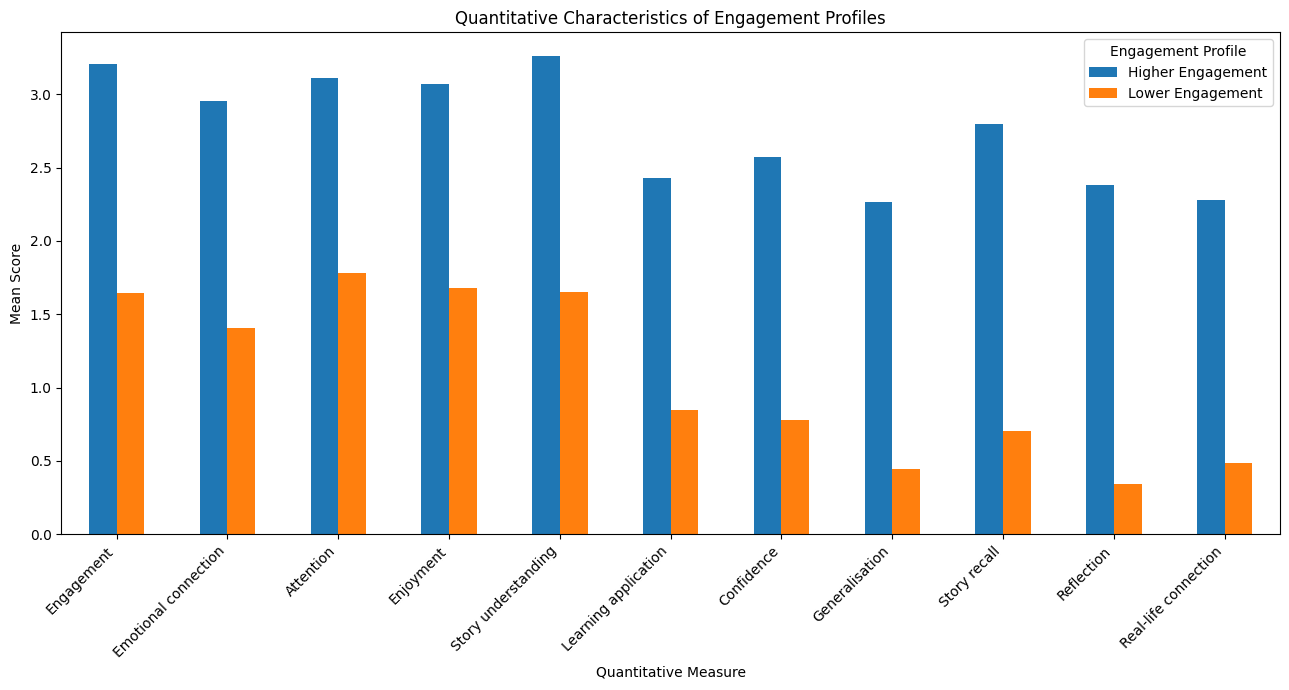

Figure saved: True


In [10]:
profile_plot_features = [
    "Mean_engagement",
    "Mean_emotional_connection",
    "Mean_attention",
    "Mean_enjoyment",
    "Mean_story_understanding",
    "Mean_learning_application",
    "Mean_confidence",
    "Mean_generalisation",
    "Mean_story_recall",
    "Mean_reflection",
    "Mean_real_life_connection"
]

profile_plot = (
    analysis_df
    .groupby("Engagement_Profile")[profile_plot_features]
    .mean()
    .T
)

profile_plot.index = [
    "Engagement",
    "Emotional connection",
    "Attention",
    "Enjoyment",
    "Story understanding",
    "Learning application",
    "Confidence",
    "Generalisation",
    "Story recall",
    "Reflection",
    "Real-life connection"
]

profile_plot.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.xlabel("Quantitative Measure")
plt.ylabel("Mean Score")
plt.title("Quantitative Characteristics of Engagement Profiles")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Engagement Profile")

plt.tight_layout()
profile_figure_path = (
    figures_folder / "engagement_profile_quantitative_comparison.png"
)

plt.savefig(
    profile_figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Figure saved:", profile_figure_path.exists())

### 6.3 Additional Profile Characteristics

Verbal participation, success percentage, and response time were examined separately because their measurement scales differed substantially from the other quantitative profile measures. Mean values were compared descriptively between the Higher and Lower Engagement profiles.

In [11]:
additional_features = [
    "Mean_verbal_participation",
    "Mean_success_percentage",
    "Mean_response_time_seconds"
]

additional_profile_summary = (
    analysis_df
    .groupby("Engagement_Profile")[additional_features]
    .agg(["mean", "std", "count"])
    .round(2)
)

additional_profile_summary

Mean_verbal_participation              \
                                        mean   std count   
Engagement_Profile                                         
Higher Engagement                       8.00  1.40    25   
Lower Engagement                        3.55  1.75     7   

                   Mean_success_percentage               \
                                      mean    std count   
Engagement_Profile                                        
Higher Engagement                    74.37  17.67    25   
Lower Engagement                     44.58  23.75     7   

                   Mean_response_time_seconds               
                                         mean    std count  
Engagement_Profile                                          
Higher Engagement                       66.42  45.06    25  
Lower Engagement                        74.96  46.28     7

## 7. NLP Sentiment Across Engagement Profiles

NLP-derived sentiment scores from therapist observational feedback were compared across the identified engagement profiles. This analysis examines whether the overall sentiment expressed in therapist observations differs between participants in the Higher and Lower Engagement profiles.

Only participants with available therapist observational feedback and corresponding sentiment scores were included in this comparison.

In [12]:
sentiment_profile_summary = (
    analysis_df
    .groupby("Engagement_Profile")["Mean_sentiment_compound"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .round(3)
)

sentiment_profile_summary

,count,mean,std,median,min,max
Engagement_Profile,,,,,,
Higher Engagement,17,0.321,0.207,0.298,0.000,0.720
Lower Engagement,6,0.147,0.345,0.173,-0.331,0.548


### 7.1 Distribution of Sentiment Scores by Engagement Profile

The distribution of participant-level mean sentiment scores was examined visually before inferential testing. This is particularly important because the engagement profiles contain unequal numbers of participants with available therapist feedback.

<Figure size 800x600 with 0 Axes>

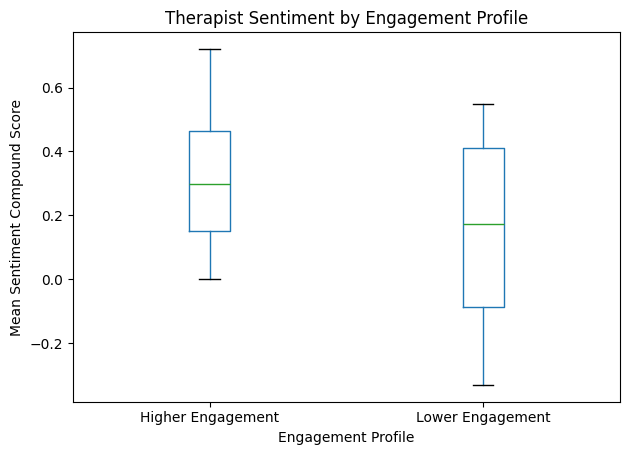

In [13]:
sentiment_plot_df = analysis_df[
    ["Engagement_Profile", "Mean_sentiment_compound"]
].dropna()

plt.figure(figsize=(8, 6))

sentiment_plot_df.boxplot(
    column="Mean_sentiment_compound",
    by="Engagement_Profile",
    grid=False
)

plt.title("Therapist Sentiment by Engagement Profile")
plt.suptitle("")
plt.xlabel("Engagement Profile")
plt.ylabel("Mean Sentiment Compound Score")

plt.tight_layout()
plt.show()

### 7.2 Statistical Comparison of Sentiment Between Profiles

A Mann–Whitney U test was used to compare participant-level sentiment scores between the Higher and Lower Engagement profiles. This non-parametric test was selected because the groups were small and unequal in size, particularly the Lower Engagement profile.

In [14]:
from scipy.stats import mannwhitneyu

higher_sentiment = analysis_df.loc[
    analysis_df["Engagement_Profile"] == "Higher Engagement",
    "Mean_sentiment_compound"
].dropna()

lower_sentiment = analysis_df.loc[
    analysis_df["Engagement_Profile"] == "Lower Engagement",
    "Mean_sentiment_compound"
].dropna()

u_stat, p_value = mannwhitneyu(
    higher_sentiment,
    lower_sentiment,
    alternative="two-sided"
)

print("Higher Engagement n:", len(higher_sentiment))
print("Lower Engagement n:", len(lower_sentiment))
print(f"Mann-Whitney U statistic: {u_stat:.3f}")
print(f"p-value: {p_value:.4f}")

Higher Engagement n: 17
Lower Engagement n: 6
Mann-Whitney U statistic: 63.000
p-value: 0.4311


#### Interpretation

Participants in the Higher Engagement profile showed a higher mean therapist sentiment score (M = 0.321) than participants in the Lower Engagement profile (M = 0.147). However, a Mann–Whitney U test indicated that this difference was not statistically significant (U = 63.00, p = .431).

Therefore, although therapist feedback was descriptively more positive for the Higher Engagement profile, the present analysis does not provide sufficient evidence of a statistically significant difference in sentiment between the two engagement profiles. This finding should be interpreted cautiously because sentiment data were available for only 23 participants, including six participants in the Lower Engagement profile.

### 7.3 Relationship Between Therapist Sentiment and Quantitative Engagement Measures

To further examine the relationship between therapist observational sentiment and quantitative engagement, Spearman rank correlations were calculated between participant-level mean sentiment scores and selected engagement-related measures.

Spearman correlation was used because of the relatively small sample with available sentiment data and because it does not require the assumption of normally distributed variables.

In [15]:
from scipy.stats import spearmanr

sentiment_features = [
    "Mean_engagement",
    "Mean_emotional_connection",
    "Mean_verbal_participation",
    "Mean_attention",
    "Mean_enjoyment",
    "Mean_story_understanding",
    "Mean_learning_application",
    "Mean_confidence",
    "Mean_generalisation",
    "Mean_story_recall",
    "Mean_reflection",
    "Mean_real_life_connection",
    "Mean_success_percentage"
]

correlation_results = []

for feature in sentiment_features:
    temp = analysis_df[
        ["Mean_sentiment_compound", feature]
    ].dropna()

    rho, p = spearmanr(
        temp["Mean_sentiment_compound"],
        temp[feature]
    )

    correlation_results.append({
        "Measure": feature,
        "N": len(temp),
        "Spearman_rho": rho,
        "p_value": p
    })

sentiment_correlations = pd.DataFrame(correlation_results)

sentiment_correlations["Absolute_rho"] = (
    sentiment_correlations["Spearman_rho"].abs()
)

sentiment_correlations = (
    sentiment_correlations
    .sort_values("Absolute_rho", ascending=False)
    .drop(columns="Absolute_rho")
)

sentiment_correlations.round(3)

,Measure,N,Spearman_rho,p_value
4,Mean_enjoyment,23,0.424,0.044
3,Mean_attention,23,0.371,0.081
5,Mean_story_understanding,23,0.369,0.083
0,Mean_engagement,23,0.365,0.087
12,Mean_success_percentage,23,0.302,0.162
1,Mean_emotional_connection,23,0.297,0.168
2,Mean_verbal_participation,23,0.258,0.235
9,Mean_story_recall,23,0.224,0.305
10,Mean_reflection,23,0.182,0.407
8,Mean_generalisation,23,-0.091,0.679


#### Interpretation

Spearman correlation analysis indicated that therapist sentiment was positively associated with several quantitative engagement measures. The strongest relationship was observed for enjoyment, which showed a moderate positive correlation with therapist sentiment (ρ = .424, p = .044, n = 23). This suggests that participants with higher mean enjoyment scores tended to receive more positively worded therapist observations.

Positive associations were also observed for attention (ρ = .371), story understanding (ρ = .369), and overall engagement (ρ = .365), although these relationships did not reach statistical significance at the .05 level.

Other quantitative measures showed weaker associations with therapist sentiment. Overall, the findings suggest that therapist sentiment may reflect some aspects of observed engagement, particularly enjoyment, but does not correspond equally with all quantitative engagement and learning measures.

Given the small sample size and the number of correlations examined, these results are interpreted as exploratory rather than confirmatory.

### 7.4 Therapist Sentiment and Enjoyment

Enjoyment showed the strongest positive association with NLP-derived therapist sentiment. A scatter plot was therefore used to visualise the participant-level relationship between mean enjoyment and mean sentiment compound scores.

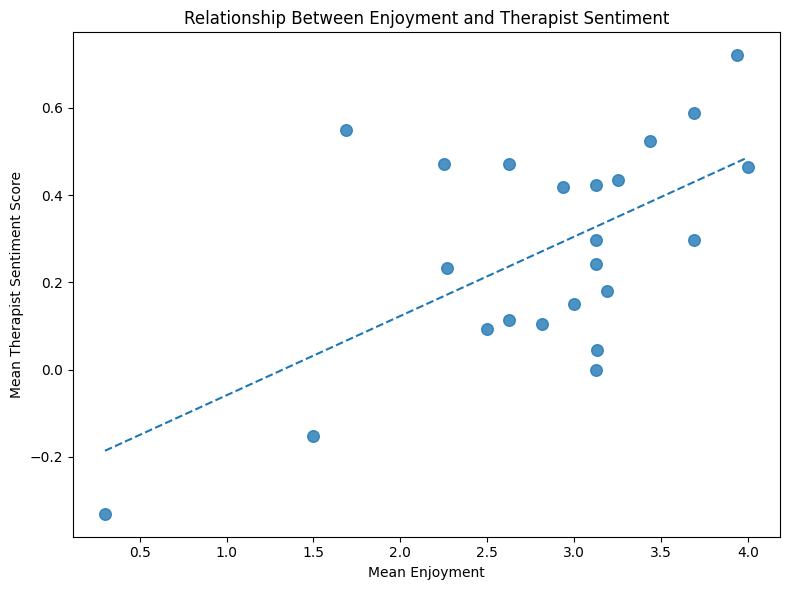

Figure saved: True


In [17]:
sentiment_enjoyment_df = analysis_df[
    [
        "Participant id",
        "Mean_enjoyment",
        "Mean_sentiment_compound"
    ]
].dropna()

plt.figure(figsize=(8, 6))

plt.scatter(
    sentiment_enjoyment_df["Mean_enjoyment"],
    sentiment_enjoyment_df["Mean_sentiment_compound"],
    s=70,
    alpha=0.8
)

# Add a simple trend line
x = sentiment_enjoyment_df["Mean_enjoyment"]
y = sentiment_enjoyment_df["Mean_sentiment_compound"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_line = np.linspace(x.min(), x.max(), 100)

plt.plot(
    x_line,
    p(x_line),
    linestyle="--"
)

plt.xlabel("Mean Enjoyment")
plt.ylabel("Mean Therapist Sentiment Score")
plt.title("Relationship Between Enjoyment and Therapist Sentiment")

plt.tight_layout()
sentiment_enjoyment_path = (
    figures_folder / "sentiment_enjoyment_relationship.png"
)

plt.savefig(
    sentiment_enjoyment_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Figure saved:", sentiment_enjoyment_path.exists())

In [18]:
[file.name for file in processed_folder.glob("*.csv")]

['cleaned_data.csv',
 'clustered_participant_data.csv',
 'participant_features.csv',
 'participant_features_with_nlp.csv']

## 8. Behavioural Themes Across Engagement Profiles

To examine how therapist-observed behavioural patterns differed between the identified engagement profiles, the session-level therapist observational data were linked with participant-level profile assignments. This allows recurring behavioural themes

In [19]:
cleaned_path = processed_folder / "cleaned_data.csv"

cleaned_df = pd.read_csv(cleaned_path)

print("Dataset shape:", cleaned_df.shape)

print("\nColumns:")
for col in cleaned_df.columns:
    print(col)

Dataset shape: (512, 75)

Columns:
Participant id
Age
Gender
Special_interest
Any co-existing disabiltiy diagnosis
Co-existing disability diagnosed details
Level of Severity
Autism Level
Stimming behaviour Identified?
Observed_stimming
Primary Goal
Other information eg anymedicalcondtion selective autism
Session number
Session date
Submitted_by
therapist_parent_name
How engaged was the participant during today's storytelling session?
Comment_Q1
How well did the participant understand that this story is personalised for them?
Comment_Q2
Did the participant demonstrate emotional connection?
Comment_Q3
How would you rate the participant’s verbal participation?
Comment_Q4
Did the participant maintain attention throughout the session?
Comment_Q5
How likely a participant was to retell and use the stories in his/her daily conversation or interaction with
their peers, carers, parents or therapists?
Comment_Q6
Did the participant show any signs of enjoyment during the session?
Comment_Q7
Did th

### 8.1 Identification of Therapist Observations

The session-level dataset contains observations submitted by different respondent types. As the NLP component of this study focuses specifically on therapist observational feedback, respondent categories were examined before extracting and integrating the relevant text.

In [20]:
print(cleaned_df["Submitted_by"].value_counts(dropna=False))

Submitted_by
T      256
P      240
P/C     16
Name: count, dtype: int64


In [21]:
print("\nTotal rows:", len(cleaned_df))
print(
    "Unique participants:",
    cleaned_df["Participant id"].nunique()
)


Total rows: 512
Unique participants: 32


In [22]:
cleaned_df["Submitted_by"].value_counts(dropna=False)

Submitted_by
T      256
P      240
P/C     16
Name: count, dtype: int64

### 8.2 Extraction of Therapist Observations

The dataset contained 256 therapist-submitted records, 240 parent-submitted records, and 16 parent/carer-submitted records. As the NLP component of this dissertation focuses on therapist observational feedback, only records coded as therapist submissions (`T`) were retained for the behavioural-theme analysis.

In [23]:
therapist_df = cleaned_df[
    cleaned_df["Submitted_by"] == "T"
].copy()

print("Therapist records:", therapist_df.shape[0])
print(
    "Participants represented:",
    therapist_df["Participant id"].nunique()
)

print("\nSessions per participant:")
print(
    therapist_df.groupby("Participant id")["Session number"]
    .nunique()
    .describe()
)

Therapist records: 256
Participants represented: 32

Sessions per participant:
count    32.0
mean      8.0
std       0.0
min       8.0
25%       8.0
50%       8.0
75%       8.0
max       8.0
Name: Session number, dtype: float64


### 8.3 Availability of Therapist Comment Fields

Before constructing the text corpus, the availability of text across the therapist comment fields was examined. This step identifies which questionnaire items contain substantive therapist observations and helps avoid including consistently empty fields in the NLP analysis.

In [24]:
comment_cols = [
    col for col in therapist_df.columns
    if col.startswith("Comment_Q")
]

comment_availability = []

for col in comment_cols:
    non_empty = (
        therapist_df[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .sum()
    )

    comment_availability.append({
        "Comment_Field": col,
        "Non_Empty_Comments": non_empty,
        "Percentage": (non_empty / len(therapist_df)) * 100
    })

comment_availability_df = (
    pd.DataFrame(comment_availability)
    .sort_values("Non_Empty_Comments", ascending=False)
)

comment_availability_df.round(2)

,Comment_Field,Non_Empty_Comments,Percentage
2,Comment_Q3,36,14.06
8,Comment_Q9,36,14.06
14,Comment_Q15,28,10.94
0,Comment_Q1,24,9.38
7,Comment_Q8,21,8.20
9,Comment_Q10,20,7.81
10,Comment_Q11,19,7.42
12,Comment_Q13,17,6.64
4,Comment_Q5,16,6.25
13,Comment_Q14,15,5.86


### 8.4 Construction of Session-Level Therapist Text

Available therapist comment fields were combined at the participant-session level to create a single textual representation of the therapist's observations for each session. Empty comment fields were excluded from the combined text rather than treated as observations.

In [25]:
def combine_comments(row):
    comments = []

    for col in comment_cols:
        value = row[col]

        if pd.notna(value):
            value = str(value).strip()

            if value:
                comments.append(value)

    return " ".join(comments)


therapist_df["combined_comments"] = (
    therapist_df.apply(combine_comments, axis=1)
)

has_text = (
    therapist_df["combined_comments"]
    .str.strip()
    .ne("")
)

print("Total therapist-session records:", len(therapist_df))
print("Records with text:", has_text.sum())
print("Records without text:", (~has_text).sum())

print(
    "Participants with at least one text observation:",
    therapist_df.loc[
        has_text, "Participant id"
    ].nunique()
)

Total therapist-session records: 256
Records with text: 134
Records without text: 122
Participants with at least one text observation: 23


### 8.5 Linking Therapist Observations to Engagement Profiles

The session-level therapist observations were linked to the participant-level engagement profiles using the participant identifier. Only therapist-session records containing textual observations were retained for subsequent behavioural-theme analysis.

In [26]:
therapist_text_df = therapist_df.loc[
    has_text,
    [
        "Participant id",
        "Session number",
        "combined_comments"
    ]
].copy()

therapist_text_df = therapist_text_df.merge(
    analysis_df[
        [
            "Participant id",
            "Cluster",
            "Engagement_Profile"
        ]
    ],
    on="Participant id",
    how="left"
)

print("Text observations:", len(therapist_text_df))

print("\nObservations by engagement profile:")
print(
    therapist_text_df["Engagement_Profile"]
    .value_counts()
)

print("\nParticipants represented by profile:")
print(
    therapist_text_df
    .groupby("Engagement_Profile")["Participant id"]
    .nunique()
)

print("\nMissing profile assignments:")
print(
    therapist_text_df["Engagement_Profile"]
    .isna()
    .sum()
)

Text observations: 134

Observations by engagement profile:
Engagement_Profile
Higher Engagement    92
Lower Engagement     42
Name: count, dtype: int64

Participants represented by profile:
Engagement_Profile
Higher Engagement    17
Lower Engagement      6
Name: Participant id, dtype: int64

Missing profile assignments:
0


### 8.6 Behavioural Theme Framework

A behavioural theme framework was used to organise therapist observations into clinically interpretable categories. The themes reflect the main behavioural and engagement constructs represented in the storytelling-session questionnaire and the dissertation research objectives.

The following themes were examined:

- Engagement and attention
- Enjoyment and positive affect
- Verbal communication and participation
- Emotional connection and expression
- Story understanding and learning
- Generalisation and real-life application
- Initiation and independence
- Distress, frustration, and disengagement

An observation could contain more than one behavioural theme because therapist comments may describe multiple behaviours within the same session.

### 8.7 Rule-Based Behavioural Theme Identification

A transparent keyword-based approach was used to identify behavioural themes within therapist observations. Keywords were selected to reflect the behavioural constructs represented in the therapist questionnaire and recurring terminology identified during the exploratory unigram, bigram, and trigram analysis.

The approach allows multiple themes to be assigned to a single observation. The rules are subsequently inspected against the original therapist comments to assess whether the resulting classifications are behaviourally meaningful.

In [27]:
theme_keywords = {
    "Engagement and Attention": [
        "engage", "engaged", "engagement",
        "attention", "attentive", "focus", "focused",
        "listening", "cooperate", "cooperation"
    ],

    "Enjoyment and Positive Affect": [
        "enjoy", "enjoyment",
        "smile", "smiling",
        "laugh", "laughed", "laughter",
        "happy", "excitement", "excited"
    ],

    "Verbal Communication and Participation": [
        "verbal", "speech", "speak", "spoke",
        "word", "words", "repeat", "repeated",
        "repetition", "said", "answer", "answered",
        "communication"
    ],

    "Emotional Connection and Expression": [
        "emotion", "emotional", "feeling", "feelings",
        "connection", "affect",
        "eye contact"
    ],

    "Story Understanding and Learning": [
        "understand", "understanding",
        "learn", "learned", "learning",
        "story", "theme", "recall", "remember"
    ],

    "Generalisation and Real-Life Application": [
        "generalise", "generalised", "generalisation",
        "real life", "real-life",
        "apply", "applied", "application",
        "home", "daily"
    ],

    "Initiation and Independence": [
        "initiate", "initiated", "initiation",
        "independent", "independently",
        "spontaneous", "without assistance",
        "without prompting"
    ],

    "Distress, Frustration and Disengagement": [
        "distress", "frustration", "frustrated",
        "bored", "boredom",
        "restless", "restlessness",
        "fatigue", "tired",
        "refused", "resistance",
        "leave classroom"
    ]
}

for theme, keywords in theme_keywords.items():
    print(f"{theme}: {len(keywords)} keywords")

Engagement and Attention: 10 keywords
Enjoyment and Positive Affect: 10 keywords
Verbal Communication and Participation: 13 keywords
Emotional Connection and Expression: 7 keywords
Story Understanding and Learning: 9 keywords
Generalisation and Real-Life Application: 10 keywords
Initiation and Independence: 8 keywords
Distress, Frustration and Disengagement: 12 keywords


### 8.8 Initial Inspection of Theme Classification Rules

Before applying the behavioural-theme framework to the full therapist-text corpus, the classification rules were tested on a sample of observations. This step was used to identify overly broad or ambiguous keywords and refine the theme definitions before the final analysis.

In [28]:
import re

def identify_themes(text):
    text = str(text).lower()
    identified = []

    for theme, keywords in theme_keywords.items():
        for keyword in keywords:

            # Phrase matching
            if " " in keyword or "-" in keyword:
                if keyword in text:
                    identified.append(theme)
                    break

            # Whole-word matching
            else:
                pattern = rf"\b{re.escape(keyword)}\b"

                if re.search(pattern, text):
                    identified.append(theme)
                    break

    return identified

In [29]:
theme_test = therapist_text_df[
    [
        "Participant id",
        "Session number",
        "Engagement_Profile",
        "combined_comments"
    ]
].sample(
    n=10,
    random_state=42
).copy()

theme_test["Identified_Themes"] = (
    theme_test["combined_comments"]
    .apply(identify_themes)
)

for _, row in theme_test.iterrows():
    print("=" * 80)
    print(
        f"Participant {row['Participant id']} | "
        f"Session {row['Session number']} | "
        f"{row['Engagement_Profile']}"
    )
    print("\nComment:")
    print(row["combined_comments"])
    print("\nThemes:")
    print(row["Identified_Themes"])
    print()

Participant 133 | Session 9 | Lower Engagement

Comment:
The participant asked, “Is this the last time I’m coming?”—a question suggesting that he had not established engagement with the intervention or the research process. During story reading, the participant stared at the therapist and remained silent.

Themes:
['Engagement and Attention', 'Story Understanding and Learning']

Participant 116 | Session 5 | Higher Engagement

Comment:
Smilling and asking questions

Themes:
[]

Participant 128 | Session 2 | Lower Engagement

Comment:
The Participant found the activity topic a bit unclear Attentive listening He repeatedly said "I can't and lets go home

Themes:
['Engagement and Attention', 'Verbal Communication and Participation', 'Generalisation and Real-Life Application']

Participant 105 | Session 8 | Higher Engagement

Comment:
He repeated the sentence, "let's go to uncle house"

Themes:
['Verbal Communication and Participation']

Participant 110 | Session 6 | Higher Engagement

Com

In [30]:
# Remove overly broad keywords
theme_keywords["Story Understanding and Learning"] = [
    word for word in theme_keywords["Story Understanding and Learning"]
    if word not in {"story", "theme"}
]

theme_keywords["Generalisation and Real-Life Application"] = [
    word for word in theme_keywords["Generalisation and Real-Life Application"]
    if word != "home"
]

# Add useful observed variants
theme_keywords["Enjoyment and Positive Affect"].extend([
    "smilling",
    "smilling and gestures"
])

theme_keywords["Verbal Communication and Participation"].extend([
    "asking questions",
    "asked questions"
])

theme_keywords["Distress, Frustration and Disengagement"].extend([
    "can't",
    "cannot",
    "lets go home",
    "let's go home",
    "silent"
])

In [31]:
for theme, keywords in theme_keywords.items():
    print(theme, ":", keywords)

Engagement and Attention : ['engage', 'engaged', 'engagement', 'attention', 'attentive', 'focus', 'focused', 'listening', 'cooperate', 'cooperation']
Enjoyment and Positive Affect : ['enjoy', 'enjoyment', 'smile', 'smiling', 'laugh', 'laughed', 'laughter', 'happy', 'excitement', 'excited', 'smilling', 'smilling and gestures']
Verbal Communication and Participation : ['verbal', 'speech', 'speak', 'spoke', 'word', 'words', 'repeat', 'repeated', 'repetition', 'said', 'answer', 'answered', 'communication', 'asking questions', 'asked questions']
Emotional Connection and Expression : ['emotion', 'emotional', 'feeling', 'feelings', 'connection', 'affect', 'eye contact']
Story Understanding and Learning : ['understand', 'understanding', 'learn', 'learned', 'learning', 'recall', 'remember']
Generalisation and Real-Life Application : ['generalise', 'generalised', 'generalisation', 'real life', 'real-life', 'apply', 'applied', 'application', 'daily']
Initiation and Independence : ['initiate', 'in

In [32]:
theme_test["Identified_Themes_Refined"] = (
    theme_test["combined_comments"]
    .apply(identify_themes)
)

for _, row in theme_test.iterrows():
    print("=" * 80)
    print(
        f"Participant {row['Participant id']} | "
        f"Session {row['Session number']} | "
        f"{row['Engagement_Profile']}"
    )

    print("\nComment:")
    print(row["combined_comments"])

    print("\nPrevious themes:")
    print(row["Identified_Themes"])

    print("\nRefined themes:")
    print(row["Identified_Themes_Refined"])

    print()

Participant 133 | Session 9 | Lower Engagement

Comment:
The participant asked, “Is this the last time I’m coming?”—a question suggesting that he had not established engagement with the intervention or the research process. During story reading, the participant stared at the therapist and remained silent.

Previous themes:
['Engagement and Attention', 'Story Understanding and Learning']

Refined themes:
['Engagement and Attention', 'Distress, Frustration and Disengagement']

Participant 116 | Session 5 | Higher Engagement

Comment:
Smilling and asking questions

Previous themes:
[]

Refined themes:
['Enjoyment and Positive Affect', 'Verbal Communication and Participation']

Participant 128 | Session 2 | Lower Engagement

Comment:
The Participant found the activity topic a bit unclear Attentive listening He repeatedly said "I can't and lets go home

Previous themes:
['Engagement and Attention', 'Verbal Communication and Participation', 'Generalisation and Real-Life Application']

Refine

In [33]:
theme_keywords["Distress, Frustration and Disengagement"].extend([
    "angry",
    "anger",
    "anxious",
    "anxiety",
    "reluctant",
    "inattentive",
    "don't want",
    "do not want"
])

In [34]:
print(
    theme_keywords[
        "Distress, Frustration and Disengagement"
    ]
)

['distress', 'frustration', 'frustrated', 'bored', 'boredom', 'restless', 'restlessness', 'fatigue', 'tired', 'refused', 'resistance', 'leave classroom', "can't", 'cannot', 'lets go home', "let's go home", 'silent', 'angry', 'anger', 'anxious', 'anxiety', 'reluctant', 'inattentive', "don't want", 'do not want']


### 8.9 Application of the Behavioural Theme Framework

Following refinement of the keyword rules using sample therapist observations, the behavioural-theme framework was applied to all substantive therapist comments. Multiple themes could be assigned to an observation where more than one behavioural construct was present.

In [35]:
therapist_text_df["Identified_Themes"] = (
    therapist_text_df["combined_comments"]
    .apply(identify_themes)
)

therapist_text_df["Number_of_Themes"] = (
    therapist_text_df["Identified_Themes"]
    .apply(len)
)

print("Total text observations:", len(therapist_text_df))

print(
    "Observations with at least one theme:",
    (therapist_text_df["Number_of_Themes"] > 0).sum()
)

print(
    "Observations with no identified theme:",
    (therapist_text_df["Number_of_Themes"] == 0).sum()
)

print(
    "Coverage percentage:",
    round(
        (therapist_text_df["Number_of_Themes"] > 0).mean() * 100,
        2
    )
)

print("\nNumber of themes assigned per observation:")
print(
    therapist_text_df["Number_of_Themes"]
    .value_counts()
    .sort_index()
)

Total text observations: 134
Observations with at least one theme: 104
Observations with no identified theme: 30
Coverage percentage: 77.61

Number of themes assigned per observation:
Number_of_Themes
0    30
1    37
2    33
3    18
4    13
5     3
Name: count, dtype: int64


### 8.10 Review of Unclassified Observations

Observations that did not receive a behavioural-theme classification were reviewed to determine whether they represented genuinely unrelated or ambiguous content or whether relevant behavioural concepts were missing from the rule-based framework. The aim was to improve theme coverage without artificially forcing all observations into predefined categories.

In [37]:
unclassified_df = therapist_text_df[
    therapist_text_df["Number_of_Themes"] == 0
][
    [
        "Participant id",
        "Session number",
        "Engagement_Profile",
        "combined_comments"
    ]
].copy()

print("Unclassified observations:", len(unclassified_df))

for _, row in unclassified_df.head(15).iterrows():
    print("=" * 80)
    print(
        f"Participant {row['Participant id']} | "
        f"Session {row['Session number']} | "
        f"{row['Engagement_Profile']}"
    )
    print(row["combined_comments"])
    print()

Unclassified observations: 30
Participant 102 | Session 6 | Lower Engagement
Decresed By 1 Minutes 45 sec

Participant 105 | Session 5 | Higher Engagement
Visible sign of distraction

Participant 105 | Session 6 | Higher Engagement
Request to read a new episode of the story Decreased by 30 seconds

Participant 105 | Session 9 | Higher Engagement
Decreased by 10 seconds

Participant 106 | Session 3 | Lower Engagement
He didn’t response

Participant 106 | Session 7 | Lower Engagement
Performance was low due to drowsiness. He didn’t response Performance was low, and the participant repeatedly asked when they would go home.

Participant 107 | Session 6 | Higher Engagement
Reading stories has strengthened his relationship with his parents

Participant 107 | Session 7 | Higher Engagement
Decreased by 30 Seconds

Participant 109 | Session 3 | Higher Engagement
He told the begging of the story

Participant 109 | Session 5 | Higher Engagement
He nodded in agreement He read the story in its enti

In [39]:
theme_keywords["Engagement and Attention"].extend([
    "distraction",
    "distracted",
    "nodded"
])

theme_keywords["Distress, Frustration and Disengagement"].extend([
    "drowsiness",
    "didn't response",
    "didn’t response",
    "performance was low"
])

theme_keywords["Emotional Connection and Expression"].extend([
    "relationship",
    "gestures",
    "gesture"
])

theme_keywords["Story Understanding and Learning"].extend([
    "told the beginning",
    "told the begging"
])

In [40]:
therapist_text_df["Identified_Themes"] = (
    therapist_text_df["combined_comments"]
    .apply(identify_themes)
)

therapist_text_df["Number_of_Themes"] = (
    therapist_text_df["Identified_Themes"].apply(len)
)

print(
    "Observations with at least one theme:",
    (therapist_text_df["Number_of_Themes"] > 0).sum()
)

print(
    "Observations with no identified theme:",
    (therapist_text_df["Number_of_Themes"] == 0).sum()
)

print(
    "Coverage percentage:",
    round(
        (therapist_text_df["Number_of_Themes"] > 0).mean() * 100,
        2
    )
)

Observations with at least one theme: 112
Observations with no identified theme: 22
Coverage percentage: 83.58


### 8.11 Behavioural Theme Distribution Across Engagement Profiles

The frequency of each behavioural theme was compared across the Higher and Lower Engagement profiles. Because the profiles contained unequal numbers of therapist observations, theme prevalence was calculated as the percentage of observations within each profile containing each theme rather than relying only on raw counts.

As multiple themes could occur within the same observation, percentages across themes are not expected to sum to 100%.

In [41]:
theme_results = []

for profile in ["Higher Engagement", "Lower Engagement"]:

    profile_data = therapist_text_df[
        therapist_text_df["Engagement_Profile"] == profile
    ]

    total_observations = len(profile_data)

    for theme in theme_keywords.keys():

        count = profile_data["Identified_Themes"].apply(
            lambda themes: theme in themes
        ).sum()

        percentage = (
            count / total_observations * 100
        )

        theme_results.append({
            "Engagement_Profile": profile,
            "Theme": theme,
            "Count": count,
            "Total_Observations": total_observations,
            "Percentage": percentage
        })


theme_profile_df = pd.DataFrame(theme_results)

theme_comparison = theme_profile_df.pivot(
    index="Theme",
    columns="Engagement_Profile",
    values="Percentage"
)

theme_comparison["Difference_Higher_minus_Lower"] = (
    theme_comparison["Higher Engagement"]
    - theme_comparison["Lower Engagement"]
)

theme_comparison = theme_comparison.sort_values(
    "Difference_Higher_minus_Lower",
    ascending=False
)

theme_comparison.round(2)

Engagement_Profile,Higher Engagement,Lower Engagement,Difference_Higher_minus_Lower
Theme,,,
Enjoyment and Positive Affect,30.43,21.43,9.01
Generalisation and Real-Life Application,7.61,7.14,0.47
Initiation and Independence,7.61,16.67,-9.06
Emotional Connection and Expression,7.61,16.67,-9.06
Story Understanding and Learning,16.30,28.57,-12.27
Verbal Communication and Participation,41.30,57.14,-15.84
Engagement and Attention,25.00,52.38,-27.38
"Distress, Frustration and Disengagement",11.96,42.86,-30.90


### 8.12 Direction of Behavioural Theme Mentions

Theme prevalence indicates how frequently a behavioural topic was mentioned but does not indicate whether the behaviour was described positively or negatively. For example, both "attention improved" and "attention was limited" relate to the Engagement and Attention theme but represent different behavioural patterns.

To provide greater contextual interpretation, directional language associated with behavioural observations was therefore examined.

In [45]:
positive_direction_terms = [
    "increased",
    "improved",
    "improvement",
    "progress",
    "high motivation",
    "highly engaging",
    "higher",
    "attentive",
    "attention increased",
    "sustained attention",
    "listening with focus",
    "listening with Focus",
    "cooperation increased",
    "sufficient cooperation",
    "acceptable",
    "willingly",
    "engaging"
]

negative_direction_terms = [
    "decreased",
    "limited",
    "little understanding",
    "absent",
    "no observable response",
    "didn't response",
    "didn’t response",
    "insufficient cooperation",
    "did not show sufficient cooperation",
    "distraction",
    "distracted",
    "restlessness",
    "distressed",
    "silent",
    "slient",
    "not observed"
]

In [46]:
engagement_comments = therapist_text_df[
    therapist_text_df["Identified_Themes"].apply(
        lambda x: "Engagement and Attention" in x
    )
][
    [
        "Participant id",
        "Session number",
        "Engagement_Profile",
        "combined_comments"
    ]
].copy()

print(
    "Engagement/Attention observations:",
    len(engagement_comments)
)

engagement_comments.head(15)

Engagement/Attention observations: 45


,Participant id,Session number,Engagement_Profile,combined_comments
0,102,2,Lower Engagement,The participant appeared to understand the act...
2,102,4,Lower Engagement,The participant appeared to expect repetition ...
3,102,5,Lower Engagement,Notable progress was observed in independent s...
11,104,5,Lower Engagement,This method can be recommended as an effective...
12,104,6,Lower Engagement,"According to the mother, the participant showe..."
14,104,9,Lower Engagement,This task demand was considered too advanced f...
15,105,2,Higher Engagement,Listening with focus Smiling Attentive Listeni...
16,105,5,Higher Engagement,Visible sign of distraction
21,106,2,Lower Engagement,He had little understanding of what activity e...
24,106,5,Lower Engagement,Due to family-related conflicts and instabilit...


In [48]:
for _, row in engagement_comments.head(15).iterrows():
    print("=" * 80)
    print(
        f"Participant {row['Participant id']} | "
        f"Session {row['Session number']} | "
        f"{row['Engagement_Profile']}"
    )
    print(row["combined_comments"])
    print()

Participant 102 | Session 2 | Lower Engagement
The participant appeared to understand the activity but showed no observable response. Marked restlessness was observed, and cooperation was absent. Didn’t answer

Participant 102 | Session 4 | Lower Engagement
The participant appeared to expect repetition of the previous story. When presented with a new story, cooperation decreased. Time was provided to allow adjustment to the new narrative. Voice imitation and intentional changes in tone during storytelling were used, resulting in laughter and increased attention Understanding of the core theme of the story remains limited. Progress is primarily observed in word repetition, though even these repetitions are not consistently used in appropriate contexts. Occasionally verbalized “grandfather.”

Participant 102 | Session 5 | Lower Engagement
Notable progress was observed in independent separation from the parent and classroom entry. The participant laughed during storytelling, and overall c

### 8.13 Classification of Engagement and Attention Direction

Engagement and attention observations were further classified according to the direction of the behavioural description. Observations containing positive indicators were classified as Positive, those containing negative indicators as Negative, and observations containing evidence of both as Mixed. Comments without sufficiently clear directional language were retained as Unclear rather than being forced into a category.

In [49]:
def classify_direction(text):
    text_lower = str(text).lower()

    positive_found = any(
        term.lower() in text_lower
        for term in positive_direction_terms
    )

    negative_found = any(
        term.lower() in text_lower
        for term in negative_direction_terms
    )

    if positive_found and negative_found:
        return "Mixed"
    elif positive_found:
        return "Positive"
    elif negative_found:
        return "Negative"
    else:
        return "Unclear"


engagement_comments["Direction"] = (
    engagement_comments["combined_comments"]
    .apply(classify_direction)
)

print("Direction counts:")
print(
    engagement_comments["Direction"]
    .value_counts()
)

print("\nDirection percentages:")
print(
    engagement_comments["Direction"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Direction counts:
Direction
Positive    20
Negative    11
Mixed        9
Unclear      5
Name: count, dtype: int64

Direction percentages:
Direction
Positive    44.44
Negative    24.44
Mixed       20.00
Unclear     11.11
Name: proportion, dtype: float64


In [50]:
for direction in ["Positive", "Negative", "Mixed", "Unclear"]:

    print("\n" + "=" * 90)
    print(direction.upper())
    print("=" * 90)

    examples = engagement_comments[
        engagement_comments["Direction"] == direction
    ].head(5)

    for _, row in examples.iterrows():
        print(
            f"\nParticipant {row['Participant id']} | "
            f"Session {row['Session number']} | "
            f"{row['Engagement_Profile']}"
        )
        print(row["combined_comments"])
        print("-" * 80)


POSITIVE

Participant 104 | Session 5 | Lower Engagement
This method can be recommended as an effective approach for increasing sustained attention in children. Initiation occurred only with prompting and guidance. No spontaneous initiation was observed. Repetition was present but lacked meaning and correct application.
--------------------------------------------------------------------------------

Participant 104 | Session 6 | Lower Engagement
According to the mother, the participant showed high motivation toward this method and enthusiasm for attending sessions and listening to new story segments. Upon entering the classroom, the participant greeted the therapist and initiated a hug. This was the first observed instance of spontaneous initiation of this behavior.
--------------------------------------------------------------------------------

Participant 105 | Session 2 | Higher Engagement
Listening with focus Smiling Attentive Listening Special during the part of the story that 

### 8.12 Visual Comparison of Behavioural Themes

Behavioural-theme prevalence was visualised using the percentage of therapist observations within each engagement profile containing each theme. Percentages were used rather than raw frequencies because the Higher and Lower Engagement profiles contained different numbers of textual observations.

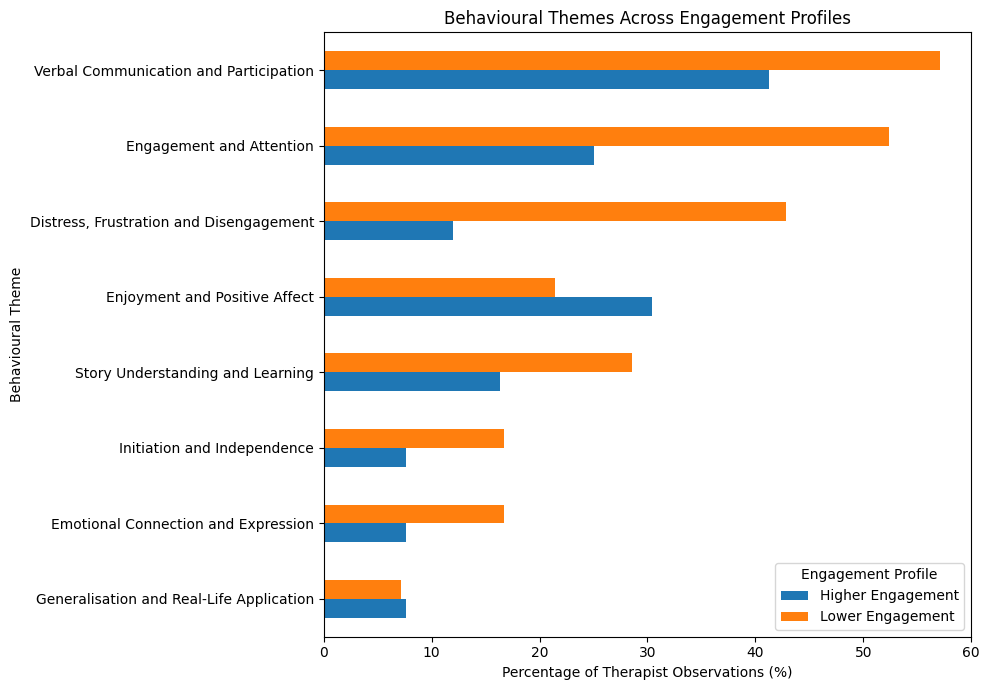

Figure saved: True


In [52]:
theme_plot_df = (
    theme_profile_df[
        ["Engagement_Profile", "Theme", "Percentage"]
    ]
    .pivot(
        index="Theme",
        columns="Engagement_Profile",
        values="Percentage"
    )
)

# Order by overall prevalence for easier interpretation
theme_plot_df["Overall"] = theme_plot_df.mean(axis=1)

theme_plot_df = (
    theme_plot_df
    .sort_values("Overall", ascending=True)
    .drop(columns="Overall")
)

ax = theme_plot_df.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.xlabel("Percentage of Therapist Observations (%)")
plt.ylabel("Behavioural Theme")
plt.title("Behavioural Themes Across Engagement Profiles")

plt.legend(
    title="Engagement Profile"
)

plt.tight_layout()
theme_figure_path = (
    figures_folder / "behavioural_themes_by_engagement_profile.png"
)

plt.savefig(
    theme_figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Figure saved:", theme_figure_path.exists())

#### Interpretation

Behavioural-theme prevalence differed descriptively across the two engagement profiles. Distress, frustration, and disengagement showed the largest difference, occurring in 42.86% of therapist observations from the Lower Engagement profile compared with 11.96% from the Higher Engagement profile. In contrast, enjoyment and positive affect were more frequently identified in observations from the Higher Engagement profile (30.43%) than the Lower Engagement profile (21.43%).

Engagement and attention, verbal communication and participation, and story understanding and learning were mentioned more frequently in observations from the Lower Engagement profile. These percentages represent the prevalence of behavioural topics within therapist observations and should not be interpreted as indicating better performance in these areas. For example, an engagement-related theme may include observations describing either strong engagement or difficulties with engagement.

Overall, the findings suggest that therapist observational feedback contained different behavioural patterns across the engagement profiles, with distress, frustration, and disengagement particularly prominent in the Lower Engagement profile.

### 8.13 Saving Behavioural Theme Results

The session-level behavioural-theme classifications and profile-level theme prevalence results were saved as processed outputs to support reproducibility and subsequent dissertation reporting.

In [53]:
# Save session-level theme classifications
theme_session_path = (
    processed_folder / "therapist_behavioural_themes.csv"
)

therapist_text_df.to_csv(
    theme_session_path,
    index=False
)

# Save profile-level theme comparison
theme_summary_path = (
    processed_folder / "behavioural_theme_profile_summary.csv"
)

theme_profile_df.to_csv(
    theme_summary_path,
    index=False
)

print("Session-level themes saved:", theme_session_path.exists())
print("Theme summary saved:", theme_summary_path.exists())

print("\nSession-level shape:", therapist_text_df.shape)
print("Summary shape:", theme_profile_df.shape)

Session-level themes saved: True
Theme summary saved: True

Session-level shape: (134, 7)
Summary shape: (16, 5)


## 9. Summary of Profile Interpretation and Integrated Analysis

This notebook interpreted the engagement profiles identified through clustering and integrated the quantitative engagement measures with NLP-derived therapist observational feedback.

Two engagement profiles were identified:

- **Higher Engagement Profile:** 25 participants
- **Lower Engagement Profile:** 7 participants

The Higher Engagement profile showed substantially higher mean scores across engagement, emotional connection, verbal participation, attention, enjoyment, story understanding, learning application, confidence, generalisation, story recall, reflection, real-life connection, and intervention success.

NLP-derived therapist sentiment was also examined across the profiles. Mean sentiment was more positive for the Higher Engagement profile (M = 0.321) than for the Lower Engagement profile (M = 0.147), although this difference was not statistically significant (Mann–Whitney U = 63.00, p = .431).

Spearman correlation analysis showed that therapist sentiment had its strongest association with participant enjoyment (ρ = .424, p = .044, n = 23). Other positive associations with attention, story understanding, and overall engagement did not reach statistical significance. Given the small sample and multiple comparisons, these findings were treated as exploratory.

Behavioural-theme analysis provided additional contextual information from therapist observations. Distress, frustration, and disengagement were substantially more prevalent in observations from the Lower Engagement profile (42.86%) than the Higher Engagement profile (11.96%). Enjoyment and positive affect were more prevalent in observations from the Higher Engagement profile (30.43%) than the Lower Engagement profile (21.43%).

Other behavioural themes reflected the frequency with which particular topics were discussed by therapists and were therefore interpreted as theme prevalence rather than direct indicators of better or worse behavioural performance.

Overall, the integrated findings demonstrate that quantitative engagement profiles can be supplemented by NLP analysis of therapist observational feedback. The textual observations provide additional behavioural context that is not fully represented by numerical engagement measures alone.

In [54]:
output_files = [
    processed_folder / "clustered_participant_data.csv",
    processed_folder / "participant_features_with_nlp.csv",
    processed_folder / "therapist_behavioural_themes.csv",
    processed_folder / "behavioural_theme_profile_summary.csv",
]

print("PROCESSED OUTPUTS")
print("-" * 50)

for path in output_files:
    print(f"{path.name}: {path.exists()}")

print("\nFIGURES")
print("-" * 50)

for path in figures_folder.glob("*.png"):
    print(path.name)

print("\nNotebook 05 analysis complete.")

PROCESSED OUTPUTS
--------------------------------------------------
clustered_participant_data.csv: True
participant_features_with_nlp.csv: True
therapist_behavioural_themes.csv: True
behavioural_theme_profile_summary.csv: True

FIGURES
--------------------------------------------------
behavioural_themes_by_engagement_profile.png
Bigram.png
Elbow Method for Optiman Number of Clusters.png
engagement_profile_quantitative_comparison.png
Hierachical Clustering Dendrogram.png
nlp_behavioural_bigrams.png
nlp_sentiment_polarity.png
nlp_top20_behaviour_terms.png
PCA Visualisation of K-Means Participant Clusters.png
Profile Plot.png
sentiment_enjoyment_relationship.png
Silhouette Scores for Different Numbers of Clusters.png
Top 20 Most Frequent Terms in Therapist Comments.png

Notebook 05 analysis complete.
